In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/app")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import pyspark.sql.functions as F

from utils.spark_session import create_spark_session

with open(PROJECT_ROOT / "schema.yaml") as f:
    schema = yaml.safe_load(f)

BRONZE_PATH = schema["bronze"]["path"]
LEGAL_BRONZE = f"{BRONZE_PATH}/{schema['bronze']['tables']['legal_docs_raw']['path']}"
WIKI_BRONZE = f"{BRONZE_PATH}/{schema['bronze']['tables']['wiki_docs_raw']['path']}"

print(f"Legal docs path: {LEGAL_BRONZE}")
print(f"Wiki  docs path: {WIKI_BRONZE}")

spark = create_spark_session("explore-bronze")
print(f"Spark version: {spark.version}")

Legal docs path: s3a://cs611-project/bronze/legal_docs_raw
Wiki  docs path: s3a://cs611-project/bronze/wiki_docs_raw
:: loading settings :: url = jar:file:/usr/local/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ca8ec73c-6616-46b4-a00b-680df57bf228;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 361ms :: artifacts dl 12ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 

Spark version: 3.5.4


## 1. Schemas and row counts

In [2]:
legal_df = spark.read.format("delta").load(LEGAL_BRONZE)
wiki_df = spark.read.format("delta").load(WIKI_BRONZE)

# Rename legal's text column to 'text' so both datasets share the same name downstream.
legal_df = legal_df.withColumnRenamed("act_raw_text", "text")

print("=" * 60)
print("LEGAL DOCS (EurLex)")
print("=" * 60)
legal_df.printSchema()

print("=" * 60)
print("WIKI DOCS (non-law baseline)")
print("=" * 60)
wiki_df.printSchema()

LEGAL DOCS (EurLex)
root
 |-- CELEX: string (nullable = true)
 |-- Act_name: string (nullable = true)
 |-- Act_type: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- EUROVOC: string (nullable = true)
 |-- Treaty: string (nullable = true)
 |-- Legal_basis_celex: string (nullable = true)
 |-- Authors: string (nullable = true)
 |-- Procedure_number: string (nullable = true)
 |-- Date_document: string (nullable = true)
 |-- Date_publication: string (nullable = true)
 |-- First_entry_into_force: string (nullable = true)
 |-- Temporal_status: string (nullable = true)
 |-- Act_cites: string (nullable = true)
 |-- Cites_links: string (nullable = true)
 |-- Act_ammends: string (nullable = true)
 |-- Ammends_links: string (nullable = true)
 |-- Eurlex_link: string (nullable = true)
 |-- ELI_link: string (nullable = true)
 |-- Proposal_link: string (nullable = true)
 |-- Oeil_link: string (nullable = true)
 |-- Additional_info: string (nullable = true)
 |-- text: string (nullab

In [3]:
print(f"Legal docs row count: {legal_df.count():,}")
print(f"Wiki docs  row count: {wiki_df.count():,}")

Legal docs row count: 58,001
Wiki docs  row count: 56,381


In [4]:
def snapshot_summary(df, label):
    if "snapshot_date" in df.columns:
        print(f"{label} per snapshot_date:")
        df.groupBy("snapshot_date").count().orderBy("snapshot_date").show(50, truncate=False)
    else:
        print(f"{label} has no snapshot_date column (single-snapshot dataset).")

snapshot_summary(legal_df, "Legal docs")
snapshot_summary(wiki_df, "Wiki docs")

Legal docs per snapshot_date:


[Stage 22:===================================================>    (22 + 2) / 24]

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|1983-01-01   |4343 |
|1984-01-01   |1274 |
|1985-01-01   |1300 |
|1986-01-01   |1617 |
|1987-01-01   |1590 |
|1988-01-01   |1585 |
|1989-01-01   |1461 |
|1990-01-01   |1562 |
|1991-01-01   |1720 |
|1992-01-01   |1757 |
|1993-01-01   |2137 |
|1994-01-01   |2272 |
|1995-01-01   |3920 |
|1996-01-01   |3396 |
|1997-01-01   |3677 |
|1998-01-01   |3788 |
|1999-01-01   |3904 |
|2000-01-01   |3624 |
|2001-01-01   |3576 |
|2002-01-01   |3191 |
|2003-01-01   |3217 |
|2004-01-01   |3090 |
+-------------+-----+

Wiki docs has no snapshot_date column (single-snapshot dataset).


## 2. Sample rows

Look at raw content. Long text fields are truncated to 500 chars in the printout to keep it readable.

In [5]:
def show_full_rows(df, label, n=3, truncate_at=500):
    rows = df.limit(n).collect()
    for i, row in enumerate(rows):
        print(f"\n{'=' * 60}\n{label} ROW {i + 1}\n{'=' * 60}")
        for col_name, val in row.asDict().items():
            if isinstance(val, str) and len(val) > truncate_at:
                print(f"\n--- {col_name} (length={len(val):,}) ---")
                print(val[:truncate_at] + "  ...[truncated]")
            else:
                print(f"{col_name}: {val}")

show_full_rows(legal_df, "LEGAL")

[Stage 27:>                                                         (0 + 1) / 1]


LEGAL ROW 1
CELEX: 31992D0580
Act_name: 92/580/EEC: Council Decision of 13 November 1992 on the signing and conclusion of the International Sugar Agreement 1992
Act_type: Decision
Status: Not in Force
EUROVOC: fructose; signature of an agreement; global agreement; commodity agreement
Treaty: TEEC
Legal_basis_celex: 11957E113
Authors: European Council
Procedure_number: 103331
Date_document: 1992-11-13
Date_publication: 1992-12-23
First_entry_into_force: 1992-11-13
Temporal_status: 2007-12-31
Act_cites: None
Cites_links: None
Act_ammends: None
Ammends_links: None
Eurlex_link: https://eur-lex.europa.eu/legal-content/EN/ALL/?uri=CELEX:31992D0580
ELI_link: http://data.europa.eu/eli/dec/1992/580/oj
Proposal_link: https://eur-lex.europa.eu/legal-content/EN/ALL/?uri=CELEX:21992A1223(01)
Oeil_link: None
Additional_info: None

--- text (length=1,206) ---
23.12.1992 EN Official Journal of the European Communities L 379/15 COUNCIL DECISION of 13 November 1992 on the signing and conclusion of the 

In [6]:
show_full_rows(wiki_df, "WIKI")

[Stage 37:================================================>         (5 + 1) / 6]


WIKI ROW 1
id: 64515138
url: https://en.wikipedia.org/wiki/Facebook%2C%20Inc.%20v.%20Duguid
title: Facebook, Inc. v. Duguid

--- text (length=1,281) ---
"Facebook, Inc. v. Duguid, 592 U.S. ___ (2021), was a United States Supreme Court case related to the definition and function of auto dialers under the Telephone Consumer Protection Act of 1991 (TCPA) to send unsolicited text messages. In a unanimous decision based on statutory interpretation of the TCPA, the Supreme Court ruled that auto dialers are defined by their function to either store or produce telephone numbers from a random or sequential number generator.

Background 
The Telephone Con  ...[truncated]

WIKI ROW 2
id: 64597748
url: https://en.wikipedia.org/wiki/Bridget%20R.%20Cooks
title: Bridget R. Cooks

--- text (length=2,134) ---
"Bridget R. Cooks is an American scholar, writer, curator, and academic. She is a professor who holds a joint appointment in the Department of African American Studies and the Department of Art H

In [7]:
TEXT_COL = "text"

assert TEXT_COL in legal_df.columns, (
    f"Column '{TEXT_COL}' not in legal_df. Available columns: {legal_df.columns}"
)
assert TEXT_COL in wiki_df.columns, (
    f"Column '{TEXT_COL}' not in wiki_df. Available columns: {wiki_df.columns}"
)

In [8]:
def length_summary(df, text_col, label):
    stats = (
        df.withColumn("char_count", F.length(text_col))
          .withColumn("word_count", F.size(F.split(F.col(text_col), r"\s+")))
          .agg(
              F.count("*").alias("rows"),
              F.min("word_count").alias("min_words"),
              F.expr("percentile_approx(word_count, 0.25)").alias("p25_words"),
              F.expr("percentile_approx(word_count, 0.50)").alias("median_words"),
              F.expr("percentile_approx(word_count, 0.75)").alias("p75_words"),
              F.expr("percentile_approx(word_count, 0.95)").alias("p95_words"),
              F.max("word_count").alias("max_words"),
              F.avg("word_count").alias("avg_words"),
          )
    )
    print(f"\n{label} word-count summary:")
    stats.show(truncate=False)

length_summary(legal_df, TEXT_COL, "LEGAL DOCS")
length_summary(wiki_df, TEXT_COL, "WIKI DOCS")


LEGAL DOCS word-count summary:


+-----+---------+---------+------------+---------+---------+---------+-----------------+
|rows |min_words|p25_words|median_words|p75_words|p95_words|max_words|avg_words        |
+-----+---------+---------+------------+---------+---------+---------+-----------------+
|58001|-1       |376      |523         |916      |3031     |302790   |1037.283098567266|
+-----+---------+---------+------------+---------+---------+---------+-----------------+


WIKI DOCS word-count summary:


[Stage 45:==================================================>     (10 + 1) / 11]

+-----+---------+---------+------------+---------+---------+---------+-----------------+
|rows |min_words|p25_words|median_words|p75_words|p95_words|max_words|avg_words        |
+-----+---------+---------+------------+---------+---------+---------+-----------------+
|56381|-1       |48       |103         |227      |591      |15642    |183.4544261364644|
+-----+---------+---------+------------+---------+---------+---------+-----------------+



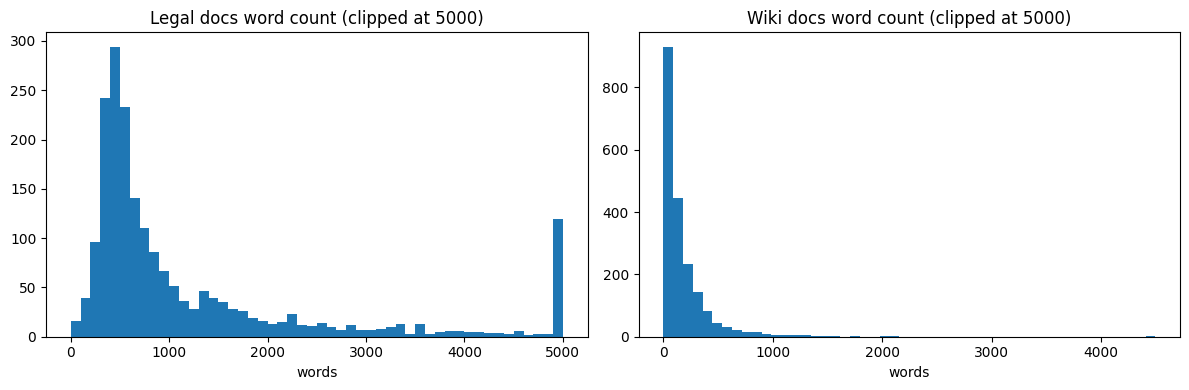

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def word_counts_pdf(df, text_col, sample_n=2000):
    return (
        df.withColumn("word_count", F.size(F.split(F.col(text_col), r"\s+")))
          .select("word_count")
          .limit(sample_n)
          .toPandas()
    )

legal_wc = word_counts_pdf(legal_df, TEXT_COL)
wiki_wc = word_counts_pdf(wiki_df, TEXT_COL)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(legal_wc["word_count"].clip(upper=5000), bins=50)
axes[0].set_title("Legal docs word count (clipped at 5000)")
axes[0].set_xlabel("words")
axes[1].hist(wiki_wc["word_count"].clip(upper=5000), bins=50)
axes[1].set_title("Wiki docs word count (clipped at 5000)")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

## 4. Language distribution

EurLex documents are multilingual in theory. We need to know if our specific Kaggle slice is English-only or has multiple languages, because that drives the POS tagging model choice.

In [10]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def detect_safely(text):
    if not text or len(text) < 50:
        return None
    try:
        return detect(text[:2000])
    except Exception:
        return None

detect_udf = F.udf(detect_safely)

print("Detecting language on a sample of legal docs...")
legal_lang = (
    legal_df.select(TEXT_COL).limit(500).withColumn("lang", detect_udf(F.col(TEXT_COL)))
)
legal_lang.groupBy("lang").count().orderBy(F.desc("count")).show()

print("Detecting language on a sample of wiki docs...")
wiki_lang = (
    wiki_df.select(TEXT_COL).limit(500).withColumn("lang", detect_udf(F.col(TEXT_COL)))
)
wiki_lang.groupBy("lang").count().orderBy(F.desc("count")).show()

Detecting language on a sample of legal docs...


+----+-----+
|lang|count|
+----+-----+
|  en|  500|
+----+-----+

Detecting language on a sample of wiki docs...


[Stage 64:==================================================>     (10 + 1) / 11]

+----+-----+
|lang|count|
+----+-----+
|  en|  454|
|NULL|   46|
+----+-----+



## 5. Text quality checks

Look for common bronze-layer issues that Silver will need to clean: HTML tags, weird whitespace, empty rows, encoding artefacts.

In [11]:
def quality_summary(df, text_col, label):
    summary = df.agg(
        F.count("*").alias("total"),
        F.sum(F.col(text_col).isNull().cast("int")).alias("null_text"),
        F.sum((F.length(text_col) == 0).cast("int")).alias("empty_text"),
        F.sum(F.col(text_col).rlike(r"<[^>]+>").cast("int")).alias("rows_with_html_tags"),
        F.sum(F.col(text_col).rlike(r"&[a-zA-Z]+;").cast("int")).alias("rows_with_html_entities"),
        F.sum(F.col(text_col).rlike(r"\s{3,}").cast("int")).alias("rows_with_multiple_whitespace"),
    )
    print(f"\n{label} quality checks:")
    summary.show(truncate=False)

quality_summary(legal_df, TEXT_COL, "LEGAL DOCS")
quality_summary(wiki_df, TEXT_COL, "WIKI DOCS")


LEGAL DOCS quality checks:


+-----+---------+----------+-------------------+-----------------------+-----------------------------+
|total|null_text|empty_text|rows_with_html_tags|rows_with_html_entities|rows_with_multiple_whitespace|
+-----+---------+----------+-------------------+-----------------------+-----------------------------+
|58001|24       |0         |150                |3066                   |0                            |
+-----+---------+----------+-------------------+-----------------------+-----------------------------+


WIKI DOCS quality checks:


[Stage 74:==================================================>     (10 + 1) / 11]

+-----+---------+----------+-------------------+-----------------------+-----------------------------+
|total|null_text|empty_text|rows_with_html_tags|rows_with_html_entities|rows_with_multiple_whitespace|
+-----+---------+----------+-------------------+-----------------------+-----------------------------+
|56381|2360     |0         |92                 |2                      |20336                        |
+-----+---------+----------+-------------------+-----------------------+-----------------------------+



## 6. Label column (`labels`)

In this dataset the label column is called `labels` and is multi-label: semicolon-separated practice areas like `"Agriculture & Food Safety; Trade & Customs; International & EU Law"`. We split it into individual labels to see the distribution.

Wiki has no label column, so this section only covers legal.

In [12]:
LABEL_COL = "labels"

if LABEL_COL not in legal_df.columns:
    print(f"Column '{LABEL_COL}' not found.")
    print(f"Available columns: {legal_df.columns}")
else:
    print("Sample raw label strings:")
    legal_df.select(LABEL_COL).limit(5).show(truncate=False)

    exploded = legal_df.select(
        F.explode(F.split(F.col(LABEL_COL), r"\s*;\s*")).alias("single_label")
    ).filter(F.col("single_label") != "")

    print("\nPer-label document counts (top 50, multi-label flattened):")
    exploded.groupBy("single_label").count().orderBy(F.desc("count")).show(50, truncate=False)

    distinct_individual = exploded.select("single_label").distinct().count()
    null_count = legal_df.filter(F.col(LABEL_COL).isNull()).count()
    avg_labels_per_doc = (
        legal_df.select(F.size(F.split(F.col(LABEL_COL), r"\s*;\s*")).alias("n"))
                .agg(F.avg("n"))
                .first()[0]
    )

    print(f"\nDistinct individual labels: {distinct_individual}")
    print(f"Rows with null labels: {null_count:,}")
    print(f"Average labels per document: {avg_labels_per_doc:.2f}")

Sample raw label strings:


+-----------------------------------------------------------------------+
|labels                                                                 |
+-----------------------------------------------------------------------+
|Agriculture & Food Safety; Trade & Customs; International & EU Law     |
|Labour, Employment & Social; Agriculture & Food Safety; Trade & Customs|
|Agriculture & Food Safety; Industry, Technology & IP; Trade & Customs  |
|Agriculture & Food Safety; Industry, Technology & IP                   |
|Labour, Employment & Social; Agriculture & Food Safety; Trade & Customs|
+-----------------------------------------------------------------------+


Per-label document counts (top 50, multi-label flattened):


+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|single_label                                                                                                                                                                                                                                                                          |count|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Agriculture & Food Safety                                                                                                                 

[Stage 100:====================================================>  (23 + 1) / 24]


Distinct individual labels: 10464
Rows with null labels: 10
Average labels per document: 1.98
